In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

from pathlib import Path
import re
from collections import defaultdict

In [4]:
!pwd

/Users/neara_interview/Trace_projects/hens-hurricane/earth2studio/recipes/hens/notebooks


In [43]:
beryl_era5 = xr.open_dataset("../../../../data/beryl_outputs/beryl_era5.nc")

In [44]:
beryl_era5

<xarray.Dataset> Size: 17MB
Dimensions:                  (time: 1464, lat: 20, lon: 36, season: 1)
Coordinates:
  * time                     (time) datetime64[ns] 12kB 2024-06-01 ... 2024-0...
  * lat                      (lat) float64 160B 31.88 31.62 ... 27.38 27.12
  * lon                      (lon) float64 288B -98.88 -98.62 ... -90.38 -90.12
  * season                   (season) <U4 16B '2024'
Data variables:
    u_component_of_wind_10m  (time, lat, lon) float32 4MB ...
    v_component_of_wind_10m  (time, lat, lon) float32 4MB ...
    mean_sea_level_pressure  (time, lat, lon) float32 4MB ...
    wind_speed_10m           (season, time, lat, lon) float32 4MB ...

In [6]:
beryl_era5 = beryl_era5.isel(season=0).sel(time=slice("2024-07-05", "2024-07-15"))

In [7]:
beryl_era5 = beryl_era5[
    ['wind_speed_10m', 'mean_sea_level_pressure']
]

In [8]:
beryl_era5 = beryl_era5['wind_speed_10m'].sel(
    lon=slice(-95.8, -95.0),
    lat=slice(30.1, 29.5)
).mean(['lat', 'lon'])

In [9]:
output_dir = Path("../../../../data/hurricane_outputs/houston")

# Fixed global member ranges for each checkpoint seed
seed_offsets = {
    12: 0,
    16: 20,
    17: 40,
    18: 60,
}

files_by_init = {}

for path in output_dir.glob("*.nc"):
    match = re.search(
        r"hurricanes_(\d{4}-\d{2}-\d{2}T\d{2})_pkg_seed(\d+)\.nc$",
        path.name,
    )

    if match is None:
        continue

    init_time = match.group(1)
    seed = int(match.group(2))

    files_by_init.setdefault(init_time, []).append((seed, path))

all_initialisations = []

for init_time in sorted(files_by_init):
    checkpoint_datasets = []

    for seed, path in sorted(files_by_init[init_time]):
        ds = xr.open_dataset(path)

        n_members = ds.sizes["ensemble"]
        offset = seed_offsets[seed]

        ds = ds.assign_coords(
            ensemble=np.arange(offset, offset + n_members),
            seed=("ensemble", np.full(n_members, seed)),
        )

        checkpoint_datasets.append(ds)

    combined_init = xr.concat(
        checkpoint_datasets,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

    all_initialisations.append(combined_init)

tx = xr.concat(
    all_initialisations,
    dim="time",
    coords="minimal",
    compat="override"
)

In [10]:
print(tx)

<xarray.Dataset> Size: 2GB
Dimensions:    (ensemble: 80, time: 18, lead_time: 85, lat: 41, lon: 41)
Coordinates:
  * ensemble   (ensemble) int64 640B 0 1 2 3 4 5 6 7 ... 72 73 74 75 76 77 78 79
    seed       (ensemble) int64 640B 12 12 12 12 12 12 12 ... 18 18 18 18 18 18
  * time       (time) datetime64[ns] 144B 2010-06-01 2010-07-01 ... 2019-11-01
  * lead_time  (lead_time) timedelta64[ns] 680B 0 days 00:00:00 ... 21 days 0...
  * lat        (lat) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * lon        (lon) float64 328B 260.0 260.2 260.5 260.8 ... 269.5 269.8 270.0
Data variables:
    u10m       (ensemble, time, lead_time, lat, lon) float32 823MB -1.847 ......
    v10m       (ensemble, time, lead_time, lat, lon) float32 823MB 3.942 ... ...
    msl        (ensemble, time, lead_time, lat, lon) float32 823MB 1.008e+05 ...


In [11]:
tx['w10m'] = np.sqrt(tx['u10m'] ** 2 + tx['v10m'] ** 2)

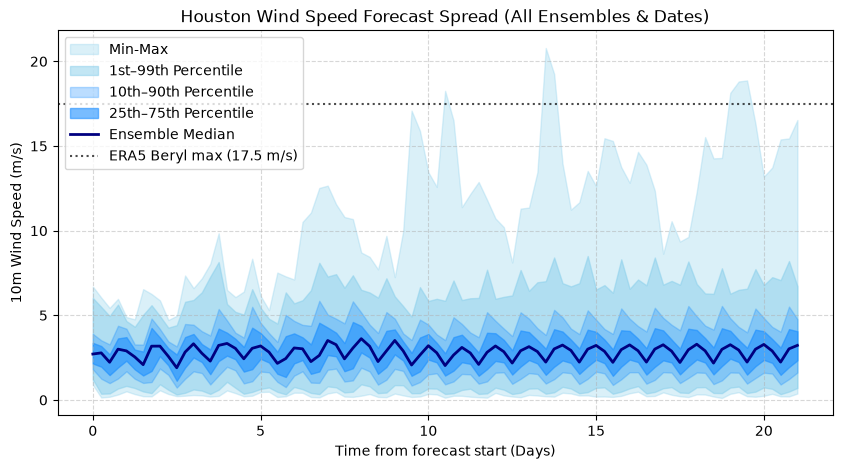

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Spatial average across Houston coordinates
# Houston metro bounding box
lat_min, lat_max = 29.5, 30.1
lon_min, lon_max = 264.2, 265.0  # -95.8 to -95.0 in 0–360 coordinates

# Select Houston region from the combined dataset
houston = tx["w10m"].sel(
    lat=slice(lat_max, lat_min),  # latitude is descending
    lon=slice(lon_min, lon_max),
)
houston_ds = houston.mean(["lat", "lon"])

# 2. Stack ensemble and time into a single 'realization' dimension (1440 realizations)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Convert lead_time to numeric days for the x-axis
lead_days = stacked.lead_time.dt.total_seconds() / 86400

# 3. Calculate percentiles along the 'realization' dimension natively in xarray
p_min = stacked.min(dim="realization").values
p1 = stacked.quantile(0.01, dim="realization").values
p10 = stacked.quantile(0.10, dim="realization").values
p25 = stacked.quantile(0.25, dim="realization").values
p50 = stacked.median(dim="realization").values
p75 = stacked.quantile(0.75, dim="realization").values
p90 = stacked.quantile(0.90, dim="realization").values
p99 = stacked.quantile(0.99, dim="realization").values
p_max = stacked.max(dim="realization").values

# 4. Plot Fan Chart
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded percentile ranges
ax.fill_between(
    lead_days, p_min, p_max, color="skyblue", alpha=0.3, label="Min-Max"
)
ax.fill_between(
    lead_days, p1, p99, color="skyblue", alpha=0.5, label="1st–99th Percentile"
)
ax.fill_between(
    lead_days, p10, p90, color="dodgerblue", alpha=0.3, label="10th–90th Percentile"
)
ax.fill_between(
    lead_days, p25, p75, color="dodgerblue", alpha=0.6, label="25th–75th Percentile"
)

# Median and Worst-Case Lines
ax.plot(lead_days, p50, color="navy", linewidth=2, label="Ensemble Median")
# ax.plot(
#     lead_days,
#     p_max,
#     color="crimson",
#     linestyle="--",
#     linewidth=1.5,
#     label="Max Worst-Case",
# )

# Reference Threshold line (e.g., Tropical Storm strength 17.5 m/s)
ax.axhline(
    17.5, color="black", linestyle=":", alpha=0.7, label="ERA5 Beryl max (17.5 m/s)"
)

ax.set_xlabel("Time from forecast start (Days)")
ax.set_ylabel("10m Wind Speed (m/s)")
ax.set_title("Houston Wind Speed Forecast Spread (All Ensembles & Dates)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

plt.show()

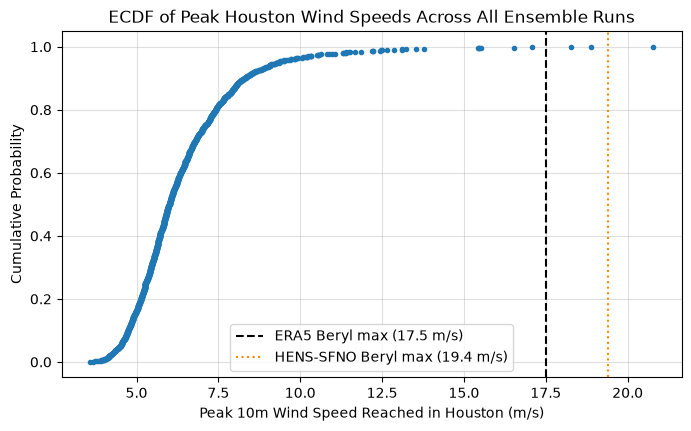

In [15]:
# Get the peak wind speed per realization
max_winds_per_sim = stacked.max(dim="lead_time").values

fig, ax = plt.subplots(figsize=(8, 4.5))

# Plot cumulative probability
sorted_winds = np.sort(max_winds_per_sim)
y_vals = np.arange(1, len(sorted_winds) + 1) / len(sorted_winds)

ax.plot(sorted_winds, y_vals, marker=".", linestyle="none", color="tab:blue")

ax.axvline(17.5, color="k", ls="--", label="ERA5 Beryl max (17.5 m/s)")
ax.axvline(19.4, color="darkorange", ls=":", label="HENS-SFNO Beryl max (19.4 m/s)")

ax.set_xlabel("Peak 10m Wind Speed Reached in Houston (m/s)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("ECDF of Peak Houston Wind Speeds Across All Ensemble Runs")
ax.grid(True, alpha=0.4)
ax.legend()

plt.show()

## Cyclone tracking

In [17]:
# ibtracs = pd.read_csv(
#     "../../../../data/beryl_outputs/ibtracs.NA.list.v04r01.csv",
#     low_memory=False,
#     skiprows=[1],
#     keep_default_na=False,
#     # parse_dates=True
#     )

In [18]:
# ibtracs = ibtracs[
#     (ibtracs.BASIN == "NA") &
#     (ibtracs.SEASON >= 1980)
# ].copy()

In [19]:
# ibtracs['ISO_TIME'] = pd.to_datetime(ibtracs['ISO_TIME'])

In [20]:
# cols = [
#     "SID", "SEASON", "NAME", "ISO_TIME",
#     "LAT", "LON", "USA_STATUS",
#     # "USA_SSHS",
#     "USA_WIND", "USA_PRES",
#     # "USA_R34_NE", "USA_R34_SE", "USA_R34_SW", "USA_R34_NW",
#     # "USA_R64_NE", "USA_R64_SE", "USA_R64_SW", "USA_R64_NW",
#     # "DIST2LAND", "LANDFALL",
# ]

# ibtracs = ibtracs[cols].copy()

In [21]:
# gdf = gpd.GeoDataFrame(
#     ibtracs.copy(),
#     geometry=gpd.points_from_xy(
#         ibtracs["LON"],
#         ibtracs["LAT"]
#     ),
#     crs="EPSG:4326"
# ).to_crs("EPSG:5070")

In [22]:
# print(gdf)

In [23]:
root = Path("../../../../data/hurricane_outputs/cyclones")

# Group files by initialisation time
files_by_init = defaultdict(list)

for file in sorted(root.glob("**/*.nc")):
    match = re.search(
        r"tracks_pkg_(\d+)_(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})_batch_(\d+)\.nc$",
        file.name,
    )

    if match is None:
        # print("Skipped:", file)
        continue

    seed = int(match.group(1))
    init_time = match.group(2)
    batch = int(match.group(3))

    files_by_init[init_time].append((seed, batch, file))

# Combine batches for each initialisation
tracks_by_init = {}

for init_time, items in sorted(files_by_init.items()):
    arrays = []

    for seed, batch, file in sorted(items, key=lambda x: (x[0], x[1])):
        # print("Opening:", file)

        da = xr.open_dataarray(file)

        # Preserve the checkpoint seed
        da = da.assign_coords(
            seed=("ensemble", np.full(da.sizes["ensemble"], seed))
        )

        arrays.append(da)

    # Concatenate batch/member files
    tracks_by_init[init_time] = xr.concat(
        arrays,
        dim="ensemble",
        coords="minimal",
        compat="override",
    )

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/76808048.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/76808048.py:41: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_by_init[init_time] = xr.concat(
/var/folders/4w/

In [24]:
tracks_all = xr.concat(
    list(tracks_by_init.values()),
    dim="time",
    coords="minimal",
    compat="override",
)

/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/2546155076.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  tracks_all = xr.concat(


In [25]:
print(tracks_all)

<xarray.DataArray (ensemble: 80, time: 18, path_id: 99, step: 85, variable: 4)> Size: 388MB
array([[[[[ 4.67626696e+01,  2.01484742e+01,  9.98191016e+04,
            8.82364941e+00],
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan],
          ...,
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan],
          [            nan,             nan,             nan,
                       nan]],

         [[ 1.59883488e+01,  6.38486625e+01,  9.93395469e+04,
            1.54964266e+01],
          [ 1.61499261e+01,  6.37188809e+01,  9.94542422e+04,
            1.81205692e+01],
          [ 1.69042264e+01,  6.34236695e+01,  9.94816016e+04,
            1.54200306e+01],
...
          [            nan,             nan,             nan,
      

(array([2.38390e+04, 1.30452e+05, 1.53003e+05, 6.40550e+04, 3.34880e+04,
        1.71580e+04, 1.58700e+03, 3.90000e+01, 4.00000e+00, 2.00000e+00]),
 array([ 1.22988653,  6.87833037, 12.52677422, 18.17521806, 23.8236619 ,
        29.47210574, 35.12054958, 40.76899343, 46.41743727, 52.06588111,
        57.71432495]),
 <BarContainer object of 10 artists>)

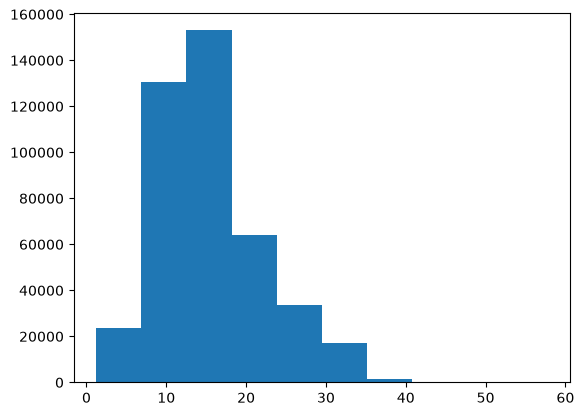

In [26]:
plt.hist(tracks_all.sel(variable="tcw10m").values.flatten())

(array([2.81000e+02, 3.21400e+03, 8.56600e+03, 1.58090e+04, 2.59110e+04,
        6.11530e+04, 1.69710e+05, 1.35065e+05, 3.86400e+03, 5.40000e+01]),
 array([ 92561.125  ,  93700.63125,  94840.1375 ,  95979.64375,
         97119.15   ,  98258.65625,  99398.1625 , 100537.66875,
        101677.175  , 102816.68125, 103956.1875 ]),
 <BarContainer object of 10 artists>)

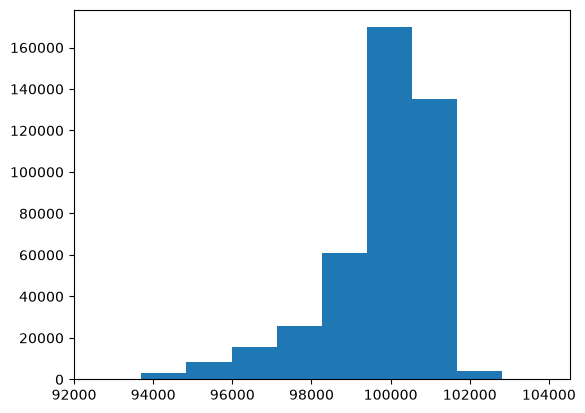

In [27]:
plt.hist(tracks_all.sel(variable="tcmsl").values.flatten())

<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/1323069605.py:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",


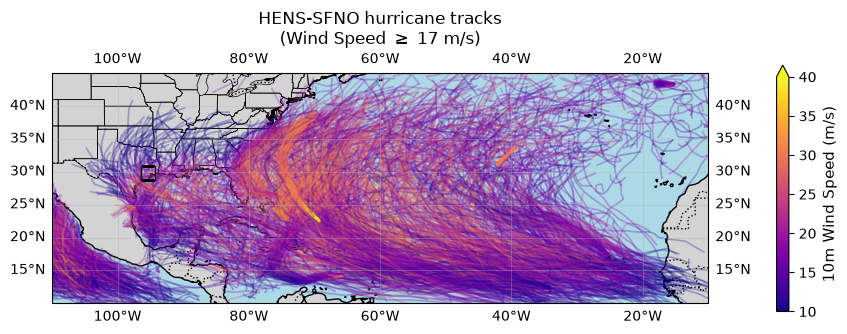

In [55]:
# -------------------------------------------------------------------------
# 1. Process IBTrACS GeoDataFrame for Hurricane Beryl
# -------------------------------------------------------------------------
# # Filter Beryl (ensure ISO_TIME is datetime)
# beryl_df = gdf[gdf["NAME"].str.upper() == "BERYL"].copy()
# beryl_df["ISO_TIME"] = pd.to_datetime(beryl_df["ISO_TIME"])

# # Filter for the relevant period matching your forecast window (e.g., July 2024)
# beryl_df = beryl_df[
#     (beryl_df["ISO_TIME"] >= "2024-07-01")
#     & (beryl_df["ISO_TIME"] <= "2024-07-15")
# ].sort_values("ISO_TIME")

# # Use direct numeric LAT/LON coordinates for Cartopy (to bypass metric geometry projection issues)
# beryl_lon = beryl_df["LON"].values
# beryl_lat = beryl_df["LAT"].values
# # Convert knots (USA_WIND) to m/s if necessary (1 knot ≈ 0.514444 m/s)
# beryl_wind = beryl_df["USA_WIND"].astype(float).values * 0.514444

# -------------------------------------------------------------------------
# 2. Process Ensemble Tracker Data
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -10, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Wind speed colormap bounds
vmin, vmax = 10, 40
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

ensembles = tracks_all.ensemble.values
times = tracks_all.time.values
paths = tracks_all.path_id.values

# -------------------------------------------------------------------------
# 3. Plot Ensemble Tracks (With Jump & Zero-Filtering)
# -------------------------------------------------------------------------
for ensemble_idx in range(len(ensembles)):
    for time_idx in range(len(times)):
        for path_idx in range(len(paths)):

            x = lon[ensemble_idx, time_idx, path_idx, :]
            y = lat[ensemble_idx, time_idx, path_idx, :]
            w = wind[ensemble_idx, time_idx, path_idx, :]

            # Filter tracks with max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            # 1. Mask NaNs AND invalid 0.0 lat/lon padding entries
            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v, w_v = x[valid], y[valid], w[valid]

            if len(x_v) < 2:
                continue

            # 2. Remove non-physical jumps across the 180°/360° boundary (> 5 degrees per step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            clean_steps = np.ones(len(x_v) - 1, dtype=bool)
            clean_steps[
                (lon_diffs > 5.0) | (lat_diffs > 5.0)
            ] = False  # Flag artificial jumps

            # Build line segments only for valid consecutive steps
            points = np.array([x_v, y_v]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Keep only clean segments
            segments = segments[clean_steps]
            w_segments = w_v[:-1][clean_steps]

            if len(segments) == 0:
                continue

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidth=1.2,
                alpha=0.3,
                transform=projection,
            )
            lc.set_array(w_segments)
            ax.add_collection(lc)

# -------------------------------------------------------------------------
# 4. Plot IBTrACS Beryl Track On Top
# -------------------------------------------------------------------------
# if len(beryl_lon) > 1:
#     # Option A: Color-coded track line for Beryl
#     valid_b = ~np.isnan(beryl_lon) & ~np.isnan(beryl_lat) & ~np.isnan(beryl_wind)
#     bx_v, by_v, bw_v = (
#         beryl_lon[valid_b],
#         beryl_lat[valid_b],
#         beryl_wind[valid_b],
#     )

#     b_points = np.array([bx_v, by_v]).T.reshape(-1, 1, 2)
#     b_segments = np.concatenate([b_points[:-1], b_points[1:]], axis=1)

#     lc_beryl = LineCollection(
#         b_segments,
#         cmap=cmap,
#         norm=norm,
#         linewidth=3.5,
#         zorder=5,
#         transform=projection,
#     )
#     lc_beryl.set_array(bw_v[:-1])
#     ax.add_collection(lc_beryl)

#     # Option B: High-contrast black dashed outline for clarity
#     ax.plot(
#         bx_v,
#         by_v,
#         color="black",
#         linestyle="--",
#         linewidth=1.2,
#         zorder=6,
#         transform=projection,
#         label="IBTrACS (Beryl)",
#     )

#     # Scatter points along Beryl's track
#     ax.scatter(
#         bx_v,
#         by_v,
#         c=bw_v,
#         cmap=cmap,
#         norm=norm,
#         edgecolor="black",
#         linewidth=0.5,
#         s=30,
#         zorder=7,
#         transform=projection,
#     )

# -------------------------------------------------------------------------
# 5. Legend, Colorbar & Titles
# -------------------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.4, pad=0.08, extend="max")
cbar.set_label("10m Wind Speed (m/s)", fontsize=11)

# Houston coordinates
houston_lon, houston_lat = -95.37, 29.76

# Draw a square box at Houston's location
ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="k",
    markerfacecolor="none",
    markersize=10,
    markeredgewidth=1.,
    zorder=8,
    transform=projection,
)

# Annotate with a black line pointing from the bottom-right corner of the Houston box
# ax.annotate(
#     "Houston",
#     xy=(houston_lon+.3, houston_lat),  # Point to target coordinates
#     xytext=(houston_lon + 3.5, houston_lat - 2.5),  # Text location (offset to lower-right)
#     xycoords=projection._as_mpl_transform(ax),  # Geographic coordinates transform
#     textcoords=projection._as_mpl_transform(ax),
#     fontsize=11,
#     # fontweight="bold",
#     color="black",
#     zorder=10,
#     arrowprops=dict(
#         arrowstyle="-",            # Simple straight line without arrow head
#         color="black",
#         linewidth=1.5,
#         patchA=None,
#         relpos=(0.0, 1.0),         # Connect line to top-left of text
#         shrinkA=7,                 # Offset start point to align with bottom-right corner of the marker box
#     ),
# )

ax.set_title(
    "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",
    fontsize=12,
)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# ax.legend(loc="upper right", framealpha=0.9)

plt.show()

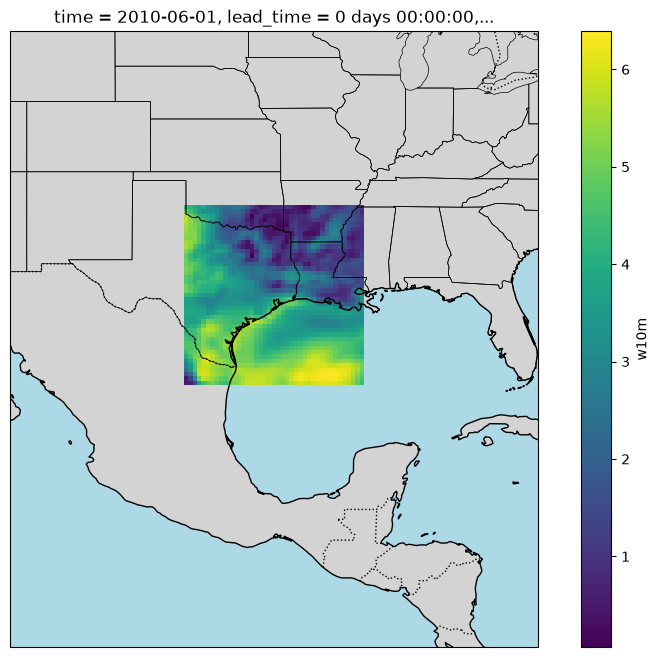

In [58]:
fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -80, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

tx['w10m'].isel(ensemble=0, time=0, lead_time=0).plot(ax=ax)

<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/734183284.py:210: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",


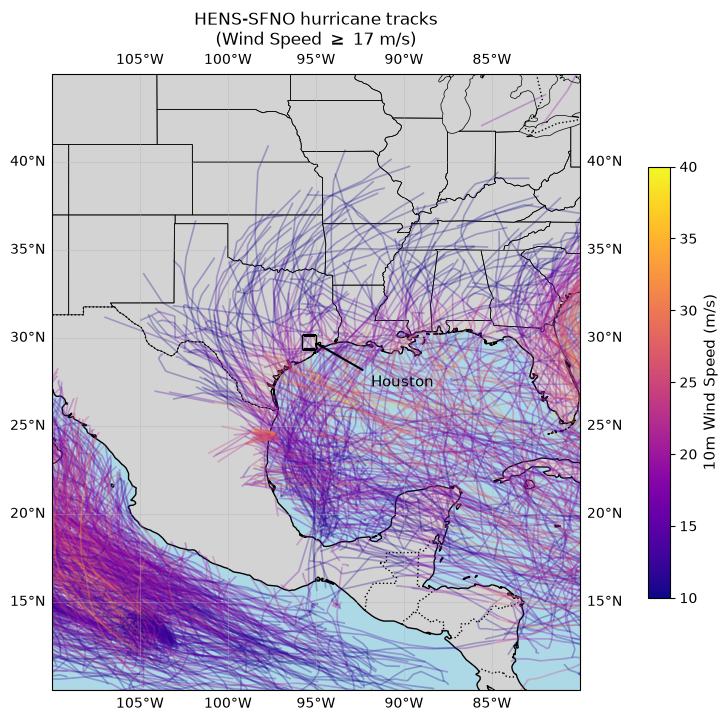

In [29]:
# -------------------------------------------------------------------------
# 1. Process IBTrACS GeoDataFrame for Hurricane Beryl
# -------------------------------------------------------------------------
# # Filter Beryl (ensure ISO_TIME is datetime)
# beryl_df = gdf[gdf["NAME"].str.upper() == "BERYL"].copy()
# beryl_df["ISO_TIME"] = pd.to_datetime(beryl_df["ISO_TIME"])

# # Filter for the relevant period matching your forecast window (e.g., July 2024)
# beryl_df = beryl_df[
#     (beryl_df["ISO_TIME"] >= "2024-07-01")
#     & (beryl_df["ISO_TIME"] <= "2024-07-15")
# ].sort_values("ISO_TIME")

# # Use direct numeric LAT/LON coordinates for Cartopy (to bypass metric geometry projection issues)
# beryl_lon = beryl_df["LON"].values
# beryl_lat = beryl_df["LAT"].values
# # Convert knots (USA_WIND) to m/s if necessary (1 knot ≈ 0.514444 m/s)
# beryl_wind = beryl_df["USA_WIND"].astype(float).values * 0.514444

# -------------------------------------------------------------------------
# 2. Process Ensemble Tracker Data
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Map setup
ax.set_extent([-110, -80, 10, 45], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Wind speed colormap bounds
vmin, vmax = 10, 40
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

ensembles = tracks_all.ensemble.values
times = tracks_all.time.values
paths = tracks_all.path_id.values

# -------------------------------------------------------------------------
# 3. Plot Ensemble Tracks (With Jump & Zero-Filtering)
# -------------------------------------------------------------------------
for ensemble_idx in range(len(ensembles)):
    for time_idx in range(len(times)):
        for path_idx in range(len(paths)):

            x = lon[ensemble_idx, time_idx, path_idx, :]
            y = lat[ensemble_idx, time_idx, path_idx, :]
            w = wind[ensemble_idx, time_idx, path_idx, :]

            # Filter tracks with max wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            # 1. Mask NaNs AND invalid 0.0 lat/lon padding entries
            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v, w_v = x[valid], y[valid], w[valid]

            if len(x_v) < 2:
                continue

            # 2. Remove non-physical jumps across the 180°/360° boundary (> 5 degrees per step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            clean_steps = np.ones(len(x_v) - 1, dtype=bool)
            clean_steps[
                (lon_diffs > 5.0) | (lat_diffs > 5.0)
            ] = False  # Flag artificial jumps

            # Build line segments only for valid consecutive steps
            points = np.array([x_v, y_v]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Keep only clean segments
            segments = segments[clean_steps]
            w_segments = w_v[:-1][clean_steps]

            if len(segments) == 0:
                continue

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidth=1.2,
                alpha=0.3,
                transform=projection,
            )
            lc.set_array(w_segments)
            ax.add_collection(lc)

# -------------------------------------------------------------------------
# 4. Plot IBTrACS Beryl Track On Top
# -------------------------------------------------------------------------
# if len(beryl_lon) > 1:
#     # Option A: Color-coded track line for Beryl
#     valid_b = ~np.isnan(beryl_lon) & ~np.isnan(beryl_lat) & ~np.isnan(beryl_wind)
#     bx_v, by_v, bw_v = (
#         beryl_lon[valid_b],
#         beryl_lat[valid_b],
#         beryl_wind[valid_b],
#     )

#     b_points = np.array([bx_v, by_v]).T.reshape(-1, 1, 2)
#     b_segments = np.concatenate([b_points[:-1], b_points[1:]], axis=1)

#     lc_beryl = LineCollection(
#         b_segments,
#         cmap=cmap,
#         norm=norm,
#         linewidth=3.5,
#         zorder=5,
#         transform=projection,
#     )
#     lc_beryl.set_array(bw_v[:-1])
#     ax.add_collection(lc_beryl)

#     # Option B: High-contrast black dashed outline for clarity
#     ax.plot(
#         bx_v,
#         by_v,
#         color="black",
#         linestyle="--",
#         linewidth=1.2,
#         zorder=6,
#         transform=projection,
#         label="IBTrACS (Beryl)",
#     )

#     # Scatter points along Beryl's track
#     ax.scatter(
#         bx_v,
#         by_v,
#         c=bw_v,
#         cmap=cmap,
#         norm=norm,
#         edgecolor="black",
#         linewidth=0.5,
#         s=30,
#         zorder=7,
#         transform=projection,
#     )

# -------------------------------------------------------------------------
# 5. Legend, Colorbar & Titles
# -------------------------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", shrink=0.7, pad=0.08)
cbar.set_label("10m Wind Speed (m/s)", fontsize=11)

# Houston coordinates
houston_lon, houston_lat = -95.37, 29.76

# Draw a square box at Houston's location
ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="k",
    markerfacecolor="none",
    markersize=10,
    markeredgewidth=1.,
    zorder=8,
    transform=projection,
)

# Annotate with a black line pointing from the bottom-right corner of the Houston box
ax.annotate(
    "Houston",
    xy=(houston_lon+.3, houston_lat),  # Point to target coordinates
    xytext=(houston_lon + 3.5, houston_lat - 2.5),  # Text location (offset to lower-right)
    xycoords=projection._as_mpl_transform(ax),  # Geographic coordinates transform
    textcoords=projection._as_mpl_transform(ax),
    fontsize=11,
    # fontweight="bold",
    color="black",
    zorder=10,
    arrowprops=dict(
        arrowstyle="-",            # Simple straight line without arrow head
        color="black",
        linewidth=1.5,
        patchA=None,
        relpos=(0.0, 1.0),         # Connect line to top-left of text
        shrinkA=7,                 # Offset start point to align with bottom-right corner of the marker box
    ),
)

ax.set_title(
    "HENS-SFNO hurricane tracks\n(Wind Speed $\geq$ 17 m/s)",
    fontsize=12,
)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# ax.legend(loc="upper right", framealpha=0.9)

plt.show()

In [36]:
houston_ds

<xarray.DataArray 'w10m' (ensemble: 80, time: 18, lead_time: 85)> Size: 490kB
array([[[3.3942964 , 2.9252415 , 1.1828315 , ..., 1.1916674 ,
         2.6780586 , 4.3168263 ],
        [5.1664224 , 4.5580697 , 3.9755752 , ..., 0.65593094,
         2.3964124 , 2.3019056 ],
        [2.0523822 , 2.818237  , 2.581438  , ..., 1.3634714 ,
         1.084798  , 3.1553822 ],
        ...,
        [1.7625375 , 1.1576222 , 2.4545896 , ..., 2.1045089 ,
         2.1297915 , 0.46240607],
        [3.2562053 , 2.7630284 , 1.5685663 , ..., 2.5155432 ,
         4.317655  , 2.4159317 ],
        [3.0848103 , 3.0991867 , 2.4481027 , ..., 4.989756  ,
         4.4124775 , 2.706667  ]],

       [[3.771013  , 3.574209  , 1.8643652 , ..., 0.94889873,
         2.3718922 , 3.5936105 ],
        [6.4614944 , 5.4928975 , 4.7952447 , ..., 1.4737948 ,
         1.6678828 , 2.771251  ],
        [2.7769883 , 2.8188734 , 2.706168  , ..., 3.6541424 ,
         7.0437007 , 6.3349166 ],
...
        [1.3832955 , 0.58860046, 2.9102201 , ..., 1.5024415 ,
         5.7977223 , 5.093941  ],
        [3.2484143 , 3.418134  , 2.2077856 , ..., 2.0416148 ,
         0.7755847 , 3.320266  ],
        [3.047363  , 2.8452213 , 1.8606882 , ..., 0.97510797,
         1.0368143 , 2.5387833 ]],

       [[4.6417904 , 3.085616  , 1.1695763 , ..., 0.4077529 ,
         1.8273711 , 2.807874  ],
        [5.5718923 , 4.9870534 , 4.6321836 , ..., 1.1083238 ,
         0.7618058 , 1.1147064 ],
        [2.744211  , 2.5455196 , 2.4131756 , ..., 2.0883155 ,
         2.113502  , 2.425165  ],
        ...,
        [1.5502676 , 0.5115746 , 2.0844433 , ..., 2.91763   ,
         4.0082335 , 2.840143  ],
        [3.7589543 , 3.3365068 , 2.3018796 , ..., 2.0886784 ,
         2.49445   , 1.4094976 ],
        [2.9669864 , 2.8820174 , 2.632485  , ..., 5.0896554 ,
         8.6174755 , 6.1651206 ]]], shape=(80, 18, 85), dtype=float32)
Coordinates:
  * ensemble   (ensemble) int64 640B 0 1 2 3 4 5 6 7 ... 72 73 74 75 76 77 78 79
    seed       (ensemble) int64 640B 12 12 12 12 12 12 12 ... 18 18 18 18 18 18
  * time       (time) datetime64[ns] 144B 2010-06-01 2010-07-01 ... 2019-11-01
  * lead_time  (lead_time) timedelta64[ns] 680B 0 days 00:00:00 ... 21 days 0...

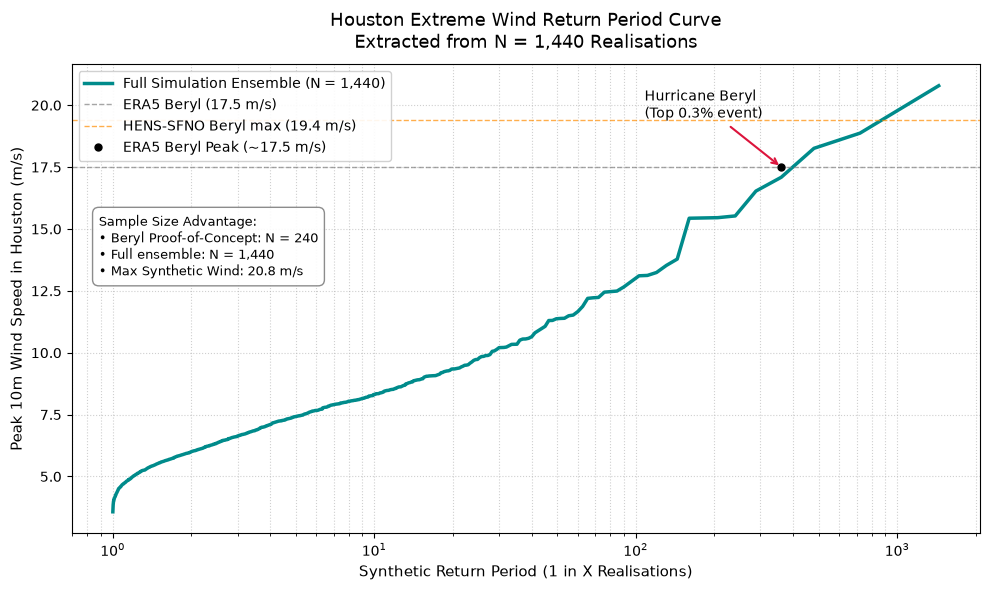

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Prepare Houston Peak Wind Speeds Across All Realizations
# -------------------------------------------------------------------------
# Mean/nearest over Houston spatial grid
houston_ds = houston.mean(["lat", "lon"]) if "lat" in houston.dims else houston

# Stack to get all 1,440 realizations (80 ensemble members * 18 init dates)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Extract the maximum wind speed achieved during each realization's forecast window
peak_winds = stacked.max(dim="lead_time").values
n_samples = len(peak_winds)

# -------------------------------------------------------------------------
# 2. Calculate Empirical Exceedance Probabilities & Return Periods
# -------------------------------------------------------------------------
# Sort peak winds in descending order
sorted_winds = np.sort(peak_winds)[::-1]

# Rank order (1 to N)
ranks = np.arange(1, n_samples + 1)

# Exceedance probability P(X >= x) using Weibull plotting position
exceedance_prob = ranks / (n_samples + 1)

# Return Period / Synthetic Frequency (in units of simulation runs / events)
# Assuming each initialization represents an independent atmospheric setup
return_period = 1 / exceedance_prob

# -------------------------------------------------------------------------
# 3. Plot Return Period / Exceedance Curve
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Main Exceedance Curve
ax.plot(
    return_period,
    sorted_winds,
    color="darkcyan",
    linewidth=2.5,
    label=f"Full Simulation Ensemble (N = {n_samples:,})",
)

# Set logarithmic scale on X-axis to emphasize rare tail events
ax.set_xscale("log")

# -------------------------------------------------------------------------
# 4. Highlight Beryl & Key Risk Thresholds
# -------------------------------------------------------------------------
# Example: Observed / ERA5 Beryl peak wind over Houston (~28 m/s, adjust as needed)
beryl_obs_wind = 17.5

# Tropical Storm & Category 1 Hurricane Thresholds
ax.axhline(
    17.5,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="ERA5 Beryl (17.5 m/s)",
)
ax.axhline(
    19.4,
    color="darkorange",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="HENS-SFNO Beryl max (19.4 m/s)",
)

# Highlight Beryl on the curve
if beryl_obs_wind <= sorted_winds.max():
    # Find closest return period for Beryl's wind speed
    idx = np.argmin(np.abs(sorted_winds - beryl_obs_wind))
    beryl_rp = return_period[idx]

    ax.plot(
        beryl_rp,
        beryl_obs_wind,
        marker="o",
        color="k",
        markersize=5,
        ls="None",
        zorder=5,
        label=f"ERA5 Beryl Peak (~{beryl_obs_wind} m/s)",
    )

    # Annotate Beryl
    ax.annotate(
        f"Hurricane Beryl\n(Top {exceedance_prob[idx]*100:.1f}% event)",
        xy=(beryl_rp, beryl_obs_wind),
        xytext=(beryl_rp * 0.3, beryl_obs_wind + 2),
        arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.5),
        fontsize=10,
        # fontweight="bold",
        color="k",
    )

# -------------------------------------------------------------------------
# 5. Formatting & Annotations
# -------------------------------------------------------------------------
ax.set_xlabel(
    "Synthetic Return Period (1 in X Realisations)",
    fontsize=11,
)
ax.set_ylabel("Peak 10m Wind Speed in Houston (m/s)", fontsize=11)
ax.set_title(
    f"Houston Extreme Wind Return Period Curve\nExtracted from N = {n_samples:,} Realisations",
    fontsize=13,
    pad=12,
)

# Add background callout box emphasizing sample size advantage
ax.text(
    0.03,
    0.55,
    f"Sample Size Advantage:\n• Beryl Proof-of-Concept: N = 240\n• Full ensemble: N = {n_samples:,}\n• Max Synthetic Wind: {sorted_winds.max():.1f} m/s",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

<>:116: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:116: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/4w/jglrh5ks0m93wsr18jhkqvyr0000gn/T/ipykernel_56651/2656574831.py:116: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  "Cyclone Track Density (Passages per $0.25^\circ$ cell)", fontsize=11


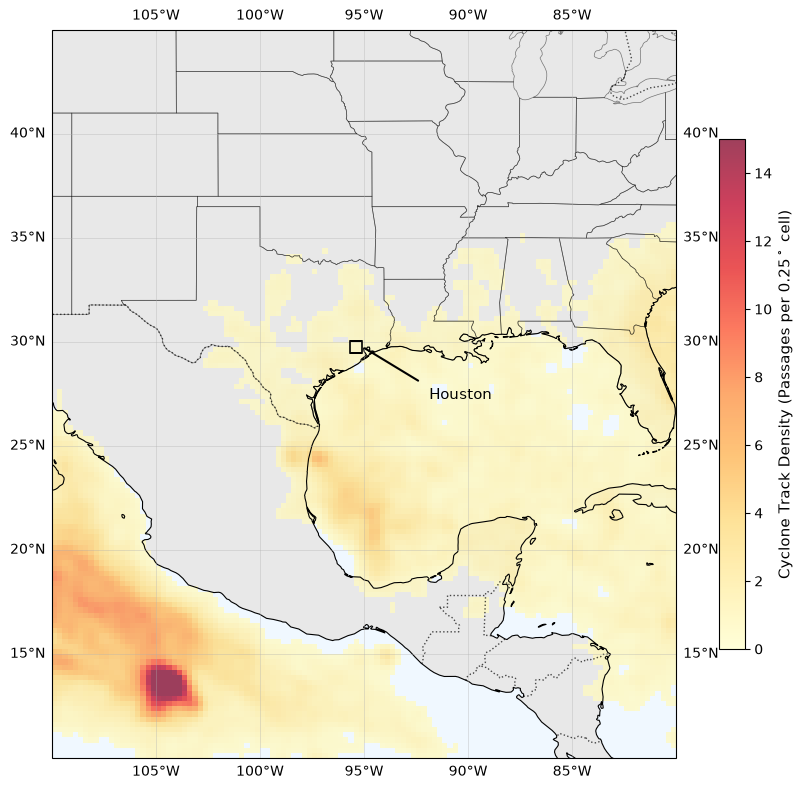

In [35]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# -------------------------------------------------------------------------
# 1. Process & Extract All Clean Coordinates
# -------------------------------------------------------------------------
lat = tracks_all.sel(variable="tclat").values
lon = tracks_all.sel(variable="tclon").values
wind = tracks_all.sel(variable="tcw10m").values

# Adjust longitudes from [0, 360] to [-180, 180]
lon = np.where(lon > 180, lon - 360, lon)

num_ensembles, num_times, num_paths, _ = lat.shape

# Collect valid track coordinates into flat arrays for 2D histogram
all_lons = []
all_lats = []

for ens in range(num_ensembles):
    for t in range(num_times):
        for p in range(num_paths):
            w = wind[ens, t, p, :]

            # Filter tracks where peak wind >= 17 m/s
            if np.all(np.isnan(w)) or np.nanmax(w) < 17.0:
                continue

            x = lon[ens, t, p, :]
            y = lat[ens, t, p, :]

            # Remove NaNs and invalid 0.0 padding
            valid = (
                ~np.isnan(x)
                & ~np.isnan(y)
                & ~np.isnan(w)
                & (x != 0.0)
                & (y != 0.0)
            )
            x_v, y_v = x[valid], y[valid]

            if len(x_v) < 2:
                continue

            # Remove non-physical jumps (> 5 deg/step)
            lon_diffs = np.abs(np.diff(x_v))
            lat_diffs = np.abs(np.diff(y_v))
            valid_steps = np.ones(len(x_v), dtype=bool)
            jump_indices = np.where((lon_diffs > 5.0) | (lat_diffs > 5.0))[0]
            if len(jump_indices) > 0:
                valid_steps[jump_indices + 1] = False

            all_lons.extend(x_v[valid_steps])
            all_lats.extend(y_v[valid_steps])

# -------------------------------------------------------------------------
# 2. Compute Spatial 2D Track Density (Grid Histogram)
# -------------------------------------------------------------------------
# Map domain bounds
lon_min, lon_max = -110, -80
lat_min, lat_max = 10, 45
grid_res = 0.25  # 0.5-degree grid cell resolution

lon_bins = np.arange(lon_min, lon_max + grid_res, grid_res)
lat_bins = np.arange(lat_min, lat_max + grid_res, grid_res)

# Compute 2D histogram (Passages per grid cell)
density, yedges, xedges = np.histogram2d(
    all_lats, all_lons, bins=[lat_bins, lon_bins]
)

# Smooth density surface for visualization clarity (sigma controls smoothing)
density_smoothed = gaussian_filter(density, sigma=1.2)
# Mask zero density areas so ocean background stays clean
density_masked = np.ma.masked_where(density_smoothed < 0.5, density_smoothed)

# -------------------------------------------------------------------------
# 3. Plot Density Heatmap with Cartopy
# -------------------------------------------------------------------------
projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(11, 8),
    subplot_kw={"projection": projection},
)

# Set map bounds and map layers
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)
ax.add_feature(cfeature.LAND, facecolor="lightgrey", alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)

# Plot smoothed track density overlay
mesh = ax.pcolormesh(
    xedges,
    yedges,
    density_masked,
    vmin=0,
    vmax=15,
    cmap="YlOrRd",
    shading="flat",
    alpha=0.75,
    transform=projection,
)

# Colorbar for track density
cbar = fig.colorbar(
    mesh, ax=ax, orientation="vertical", shrink=0.7, pad=0.04
)
cbar.set_label(
    "Cyclone Track Density (Passages per $0.25^\circ$ cell)", fontsize=11
)

# -------------------------------------------------------------------------
# 4. Houston Location & Reference Annotations
# -------------------------------------------------------------------------
houston_lon, houston_lat = -95.37, 29.76

ax.plot(
    houston_lon,
    houston_lat,
    marker="s",
    markeredgecolor="black",
    markerfacecolor="none",
    markersize=9,
    markeredgewidth=1.2,
    zorder=8,
    transform=projection,
)

ax.annotate(
    "Houston",
    xy=(houston_lon + 0.3, houston_lat),
    xytext=(houston_lon + 3.5, houston_lat - 2.5),
    xycoords=projection._as_mpl_transform(ax),
    textcoords=projection._as_mpl_transform(ax),
    fontsize=11,
    # fontweight="bold",
    color="black",
    zorder=9,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        linewidth=1.5,
        shrinkA=7,
        relpos=(0.0, 1.0),
    ),
)

total_sims = num_ensembles * num_times
# ax.set_title(
#     f"Multi-Year Cyclone Track Spatial Density Heatmap\nAggregated across N = {total_sims:,} Simulations ($\ge$17 m/s)",
#     fontsize=12,
#     pad=12,
# )
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

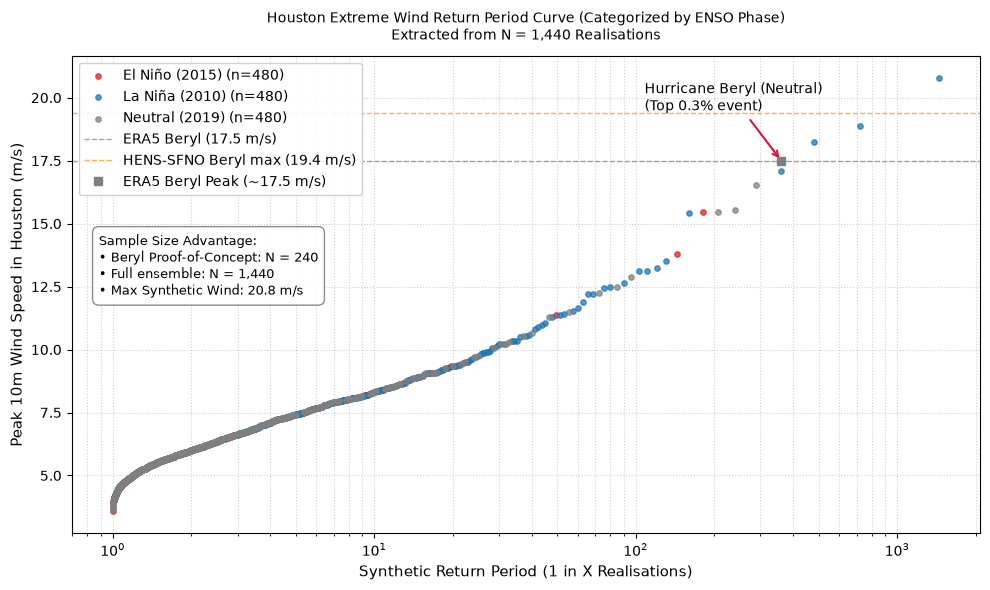

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Prepare Houston Peak Wind Speeds & Extract Initialization Years
# -------------------------------------------------------------------------
# Mean/nearest over Houston spatial grid
houston_ds = houston.mean(["lat", "lon"]) # if "lat" in houston.dims else houston

# Stack to get all realizations (ensemble * initialization time)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Extract maximum wind speed across lead_time while retaining coordinate metadata
peak_da = stacked.max(dim="lead_time")
peak_winds = peak_da.values

# Extract initialization year for each realization
years = pd.to_datetime(peak_da.time.values).year
n_samples = len(peak_winds)

# -------------------------------------------------------------------------
# 2. Calculate Empirical Exceedance Probabilities & Return Periods
# -------------------------------------------------------------------------
# Sort peak winds in descending order and reorder years accordingly
sort_idx = np.argsort(peak_winds)[::-1]
sorted_winds = peak_winds[sort_idx]
sorted_years = years[sort_idx]

# Rank order (1 to N)
ranks = np.arange(1, n_samples + 1)

# Exceedance probability P(X >= x) using Weibull plotting position
exceedance_prob = ranks / (n_samples + 1)

# Return Period / Synthetic Frequency
return_period = 1 / exceedance_prob

# -------------------------------------------------------------------------
# 3. Plot Exceedance Return Period Points Colored by ENSO Phase
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Map years to colors and legend labels
enso_config = {
    2015: ("tab:red", "El Niño (2015)"),
    2010: ("tab:blue", "La Niña (2010)"),
    2019: ("gray", "Neutral (2019)"),
}

# Plot individual points for each ENSO category
for yr, (color, label) in enso_config.items():
    mask = sorted_years == yr
    if np.any(mask):
        ax.scatter(
            return_period[mask],
            sorted_winds[mask],
            color=color,
            s=15,
            alpha=0.75,
            label=f"{label} (n={mask.sum()})",
            zorder=3,
        )

# Fallback plot for any unclassified years if present
other_mask = ~np.isin(sorted_years, list(enso_config.keys()))
if np.any(other_mask):
    ax.scatter(
        return_period[other_mask],
        sorted_winds[other_mask],
        color="lightgray",
        s=10,
        alpha=0.5,
        label="Other Years",
        zorder=2,
    )

# Set logarithmic scale on X-axis to emphasize rare tail events
ax.set_xscale("log")

# -------------------------------------------------------------------------
# 4. Highlight Beryl & Key Risk Thresholds
# -------------------------------------------------------------------------
beryl_obs_wind = 17.5

# Reference wind thresholds
ax.axhline(
    17.5,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="ERA5 Beryl (17.5 m/s)",
)
ax.axhline(
    19.4,
    color="darkorange",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="HENS-SFNO Beryl max (19.4 m/s)",
)

# Highlight Beryl on the curve
if beryl_obs_wind <= sorted_winds.max():
    idx = np.argmin(np.abs(sorted_winds - beryl_obs_wind))
    beryl_rp = return_period[idx]

    ax.plot(
        beryl_rp,
        beryl_obs_wind,
        marker="s",
        color="gray",
        markersize=6,
        ls="None",
        zorder=5,
        label=f"ERA5 Beryl Peak (~{beryl_obs_wind} m/s)",
    )

    # Annotate Beryl
    ax.annotate(
        f"Hurricane Beryl (Neutral)\n(Top {exceedance_prob[idx]*100:.1f}% event)",
        xy=(beryl_rp, beryl_obs_wind),
        xytext=(beryl_rp * 0.3, beryl_obs_wind + 2),
        arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.5),
        fontsize=10,
        color="k",
    )

# -------------------------------------------------------------------------
# 5. Formatting & Annotations
# -------------------------------------------------------------------------
ax.set_xlabel("Synthetic Return Period (1 in X Realisations)", fontsize=11)
ax.set_ylabel("Peak 10m Wind Speed in Houston (m/s)", fontsize=11)
ax.set_title(
    f"Houston Extreme Wind Return Period Curve (Categorized by ENSO Phase)\nExtracted from N = {n_samples:,} Realisations",
    fontsize=10,
    pad=12,
)

# Add background callout box
ax.text(
    0.03,
    0.50,
    f"Sample Size Advantage:\n• Beryl Proof-of-Concept: N = 240\n• Full ensemble: N = {n_samples:,}\n• Max Synthetic Wind: {sorted_winds.max():.1f} m/s",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

In [64]:
range(len(houston.lead_time.values))

range(0, 85)

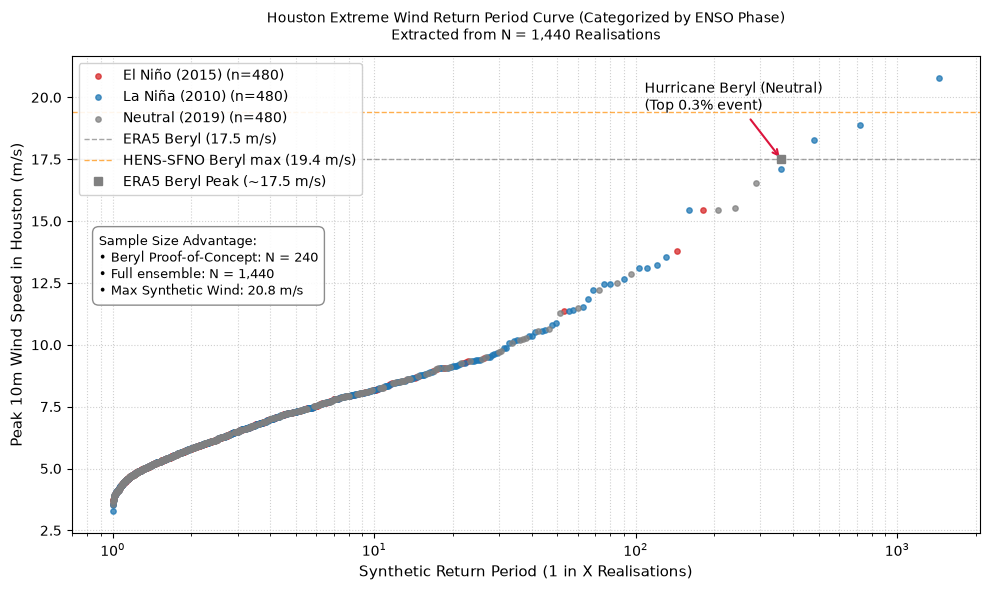

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. Prepare Houston Peak Wind Speeds & Extract Initialization Years
# -------------------------------------------------------------------------
# Mean/nearest over Houston spatial grid
houston_ds = houston.isel(lead_time=range(7*4, len(houston.lead_time.values))).mean(["lat", "lon"]) #if "lat" in houston.dims else houston

# Stack to get all realizations (ensemble * initialization time)
stacked = houston_ds.stack(realization=("ensemble", "time"))

# Extract maximum wind speed across lead_time while retaining coordinate metadata
peak_da = stacked.max(dim="lead_time")
peak_winds = peak_da.values

# Extract initialization year for each realization
years = pd.to_datetime(peak_da.time.values).year
n_samples = len(peak_winds)

# -------------------------------------------------------------------------
# 2. Calculate Empirical Exceedance Probabilities & Return Periods
# -------------------------------------------------------------------------
# Sort peak winds in descending order and reorder years accordingly
sort_idx = np.argsort(peak_winds)[::-1]
sorted_winds = peak_winds[sort_idx]
sorted_years = years[sort_idx]

# Rank order (1 to N)
ranks = np.arange(1, n_samples + 1)

# Exceedance probability P(X >= x) using Weibull plotting position
exceedance_prob = ranks / (n_samples + 1)

# Return Period / Synthetic Frequency
return_period = 1 / exceedance_prob

# -------------------------------------------------------------------------
# 3. Plot Exceedance Return Period Points Colored by ENSO Phase
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Map years to colors and legend labels
enso_config = {
    2015: ("tab:red", "El Niño (2015)"),
    2010: ("tab:blue", "La Niña (2010)"),
    2019: ("gray", "Neutral (2019)"),
}

# Plot individual points for each ENSO category
for yr, (color, label) in enso_config.items():
    mask = sorted_years == yr
    if np.any(mask):
        ax.scatter(
            return_period[mask],
            sorted_winds[mask],
            color=color,
            s=15,
            alpha=0.75,
            label=f"{label} (n={mask.sum()})",
            zorder=3,
        )

# Fallback plot for any unclassified years if present
other_mask = ~np.isin(sorted_years, list(enso_config.keys()))
if np.any(other_mask):
    ax.scatter(
        return_period[other_mask],
        sorted_winds[other_mask],
        color="lightgray",
        s=10,
        alpha=0.5,
        label="Other Years",
        zorder=2,
    )

# Set logarithmic scale on X-axis to emphasize rare tail events
ax.set_xscale("log")

# -------------------------------------------------------------------------
# 4. Highlight Beryl & Key Risk Thresholds
# -------------------------------------------------------------------------
beryl_obs_wind = 17.5

# Reference wind thresholds
ax.axhline(
    17.5,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="ERA5 Beryl (17.5 m/s)",
)
ax.axhline(
    19.4,
    color="darkorange",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="HENS-SFNO Beryl max (19.4 m/s)",
)

# Highlight Beryl on the curve
if beryl_obs_wind <= sorted_winds.max():
    idx = np.argmin(np.abs(sorted_winds - beryl_obs_wind))
    beryl_rp = return_period[idx]

    ax.plot(
        beryl_rp,
        beryl_obs_wind,
        marker="s",
        color="gray",
        markersize=6,
        ls="None",
        zorder=5,
        label=f"ERA5 Beryl Peak (~{beryl_obs_wind} m/s)",
    )

    # Annotate Beryl
    ax.annotate(
        f"Hurricane Beryl (Neutral)\n(Top {exceedance_prob[idx]*100:.1f}% event)",
        xy=(beryl_rp, beryl_obs_wind),
        xytext=(beryl_rp * 0.3, beryl_obs_wind + 2),
        arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.5),
        fontsize=10,
        color="k",
    )

# -------------------------------------------------------------------------
# 5. Formatting & Annotations
# -------------------------------------------------------------------------
ax.set_xlabel("Synthetic Return Period (1 in X Realisations)", fontsize=11)
ax.set_ylabel("Peak 10m Wind Speed in Houston (m/s)", fontsize=11)
ax.set_title(
    f"Houston Extreme Wind Return Period Curve (Categorized by ENSO Phase)\nExtracted from N = {n_samples:,} Realisations",
    fontsize=10,
    pad=12,
)

# Add background callout box
ax.text(
    0.03,
    0.50,
    f"Sample Size Advantage:\n• Beryl Proof-of-Concept: N = 240\n• Full ensemble: N = {n_samples:,}\n• Max Synthetic Wind: {sorted_winds.max():.1f} m/s",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
)

ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

In [73]:
houston_ds.where(houston_ds > 17.5, drop=True).isel(time=0)

<xarray.DataArray 'w10m' (ensemble: 3, lead_time: 6)> Size: 72B
array([[      nan,       nan,       nan,       nan,       nan,       nan],
       [18.258688,       nan,       nan,       nan,       nan,       nan],
       [      nan,       nan,       nan, 18.137339, 18.808664, 18.872221]],
      dtype=float32)
Coordinates:
  * ensemble   (ensemble) int64 24B 55 71 75
    seed       (ensemble) int64 24B 17 18 18
  * lead_time  (lead_time) timedelta64[ns] 48B 10 days 12:00:00 ... 19 days 1...
    time       datetime64[ns] 8B 2010-08-01

In [74]:
houston_ds.where(houston_ds > 17.5, drop=True).isel(time=1)

<xarray.DataArray 'w10m' (ensemble: 3, lead_time: 6)> Size: 72B
array([[      nan, 20.78786 , 19.255836,       nan,       nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan]],
      dtype=float32)
Coordinates:
  * ensemble   (ensemble) int64 24B 55 71 75
    seed       (ensemble) int64 24B 17 18 18
  * lead_time  (lead_time) timedelta64[ns] 48B 10 days 12:00:00 ... 19 days 1...
    time       datetime64[ns] 8B 2010-09-01

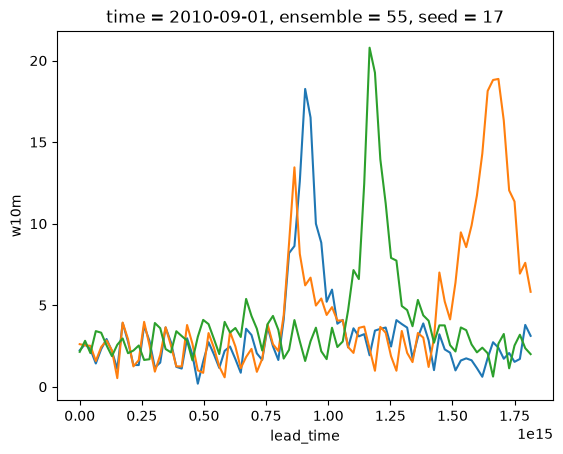

In [78]:
houston_ds.sel(time="2010-08-01", ensemble=71).plot()
houston_ds.sel(time="2010-08-01", ensemble=75).plot()
houston_ds.sel(time="2010-09-01", ensemble=55).plot()